In [1]:
import matplotlib.pyplot as plt
import math
import pandas as pd
import copy

import torch
import torch.nn as nn

from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms
from torchmetrics.classification import (MulticlassAccuracy,
                                         MulticlassPrecision,
                                         MulticlassRecall,
                                         MulticlassF1Score,
                                         MulticlassConfusionMatrix)
from sklearn.metrics import ConfusionMatrixDisplay


In [2]:
def display_images(dataset, num_images=16):
    cols = math.ceil((num_images) ** 0.5)
    rows = math.ceil(num_images / cols)

    plt.figure(figsize=(8, 8))

    for i in range(num_images):
        image, label = dataset[i]

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(f'Label: {label}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [3]:
def get_label_counts(dataset):
    label = [label for _, label in dataset]
    return pd.Series(label).value_counts().sort_index()

In [4]:
def visualize_split(train, validation, test):
    train_label_counts = get_label_counts(train)
    val_label_counts = get_label_counts(validation)
    test_label_counts = get_label_counts(test)

    counts_df = pd.DataFrame({
                            'Train': train_label_counts,
                            'Validation': val_label_counts,
                            'Test': test_label_counts})

    counts_df.plot(kind='bar', stacked=True, 
        color=['skyblue', 'lightgreen', 'lightcoral'], 
        edgecolor='black'
        )
    
    plt.title('Label Distribution')
    plt.xlabel('Digit')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [5]:
def validation_set(train_dataset, train_ratio=0.8, random_state=123):
    train_size = int(train_ratio * len(train_dataset))
    val_size = len(train_dataset) - train_size

    train_subset, val_subset = random_split(
        train_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(random_state)
    )
    return train_subset, val_subset

In [6]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.25),
            nn.Linear(128 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(p=0.25),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [7]:
def train(model, device, train_loader, val_loader, criterion, optimizer, epochs=25):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_val_loss = float('inf')
    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0.0, 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0) 

        train_loss /= train_total 
        train_acc = train_correct / train_total 

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0.0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)


        val_loss /= val_total
        val_acc = val_correct / val_total

        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(model.state_dict())


        print(f'Epoch: {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}')
        print(f'Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_acc:.4f}')

    model.load_state_dict(best_model_state)
    best_results = {'best_epoch': best_epoch,
                    'best_val_acc':  best_val_acc,
                    'best_val_loss': best_val_loss}

    print(f'\nBest Epoch: {best_epoch}'
          f'\nBest Validation Accuracy: {best_val_acc}'
          f'Best Validation Loss: {best_val_loss}')

    # Optinal to save best model to files:
    torch.save(model.state_dict(), 'best_cnn_model.pth')

    return history, best_results

In [8]:
def evaluate(
        model, device, dataloader, accuracy_metric, 
        precision_metric, recall_metric, f1_metric, 
        confusion_matrix_metric
        ):
    model.eval()
    
    accuracy_metric.reset()
    precision_metric.reset()
    recall_metric.reset()
    f1_metric.reset()
    confusion_matrix_metric.reset()
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            accuracy_metric.update(preds, labels)
            precision_metric.update(preds, labels)
            recall_metric.update(preds, labels)
            f1_metric.update(preds, labels)
            confusion_matrix_metric.update(preds, labels)

    accuracy = accuracy_metric.compute()
    precision = precision_metric.compute()
    recall = recall_metric.compute()
    f1 = f1_metric.compute()
    confusion_matrix = confusion_matrix_metric.compute().cpu().numpy()

    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 score: {f1:.4f}')
    print(f'Confusion Matrix:\n{confusion_matrix}')
    return confusion_matrix

In [9]:
def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Loss plot
    axes[0].plot(
        epochs,
        history['train_loss'],
        color='blue',
        label='Train Loss'
    )
    axes[0].plot(
        epochs,
        history['val_loss'],
        color='red',
        label='Validation Loss'
    )

    axes[0].set_title('Model Loss (Cross-Entropy)')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy plot
    axes[1].plot(
        epochs,
        history['train_acc'],
        color='blue',
        label='Train Accuracy'
    )
    axes[1].plot(
        epochs,
        history['val_acc'],
        color='red',
        label='Validation Accuracy'
    )

    axes[1].set_title('Model Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [10]:
def plot_confusion_matrix(confusion_matrix):
    display_labels = list(range(10))
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=display_labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()

In [11]:
def collect_incorrect_predictions(model, device, dataloader, num_images=16, plot=True):
    incorrect_predictions = []
    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)
            probabilities = torch.softmax(outputs, dim=1)
            confidences = probabilities.max(dim=1).values

            incorrect = predictions != labels

            incorrect_image = images[incorrect]
            incorrect_label = labels[incorrect]
            incorrect_pred = predictions[incorrect]
            incorrect_confidence = confidences[incorrect]

            for image, label, prediction, confidence in zip(
                incorrect_image,
                incorrect_label,
                incorrect_pred,
                incorrect_confidence):

                incorrect_predictions.append({
                    'image': image.detach().cpu(),
                    'true label': label.item(),
                    'predicted label': prediction.item(),
                    'confidence': confidence.item()
                })

        incorrect_predictions.sort(key=lambda result: result['confidence'], 
                                   reverse=True)

    if plot and incorrect_predictions:
        images_to_plot = min(num_images, len(incorrect_predictions))

        print(f'# of incorrect predictions: {len(incorrect_predictions)}')
        
        cols = math.ceil((images_to_plot) ** 0.5)
        rows = math.ceil(images_to_plot / cols)
    
        plt.figure(figsize=(8, 8))

        for i in range(images_to_plot):
            result = incorrect_predictions[i]

            image = result['image']
            true_label = result['true label']
            predicted_label = result['predicted label']
            confidence = result['confidence']

            plt.subplot(rows, cols, i+1)
            plt.imshow(image.squeeze(), cmap='gray')
            plt.title(f'Pred: {predicted_label} | True: {true_label}\n'
                      f'Confidence: {confidence:.2%}')
            plt.axis('off')

        plt.tight_layout()
        plt.show()


    return incorrect_predictions 




In [12]:
def main(plot = True):
    if torch.backends.mps.is_available():
        device = torch.device('mps')
    else:
        device = torch.device('cpu')

    train_dataset = datasets.MNIST(
        root='data', 
        train=True, 
        download=False, 
        transform=transforms.ToTensor())
    
    test_dataset = datasets.MNIST(
        root='data',
        train=False,
        download=False,
        transform=transforms.ToTensor())

    train_subset, validation_subset = validation_set(train_dataset, train_ratio=0.85)

    if plot:
        # Display example images of the dataset:
        display_images(train_dataset)

        # Dataset visualization plot:
        visualize_split(train_subset, validation_subset, test=test_dataset)

    # DataLoader:
    batch_size = 32
    train_loader = DataLoader(dataset=train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(dataset=validation_subset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

    model = CNN().to(device)

    # Evaluation Metrics:
    accuracy_metric = MulticlassAccuracy(num_classes=10, average='micro').to(device)
    precision_metric = MulticlassPrecision(num_classes=10, average='macro').to(device)
    recall_metric = MulticlassRecall(num_classes=10, average='macro').to(device)
    f1_metric = MulticlassF1Score(num_classes=10, average='macro').to(device)
    confusion_matrix_metric = MulticlassConfusionMatrix(num_classes=10).to(device)

    # Training:
    num_epochs = 25
    lr = 0.001
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history, best_results = train(model=model, device=device, train_loader = train_loader, 
                    val_loader = val_loader, 
                    criterion = criterion, optimizer = optimizer, 
                    epochs=num_epochs)

    confusion_matrix_val = evaluate(model=model, device=device, dataloader=val_loader, accuracy_metric=accuracy_metric,
        precision_metric=precision_metric,
        recall_metric=recall_metric,
        f1_metric=f1_metric,
        confusion_matrix_metric=confusion_matrix_metric)

    incorrect_preds_val = collect_incorrect_predictions(
        model=model, device=device, dataloader=val_loader, 
        num_images=16, plot=plot)

    if plot:
        plot_training_history(history)
        plot_confusion_matrix(confusion_matrix_val)

    # Testing:
    confusion_matrix_test = evaluate(model=model, device=device, dataloader=test_loader, 
            accuracy_metric=accuracy_metric,
            precision_metric=precision_metric,
            recall_metric=recall_metric,
            f1_metric=f1_metric,
            confusion_matrix_metric=confusion_matrix_metric)

    collect_incorrect_predictions(model=model, device=device, 
                                     dataloader=test_loader, num_images=16, plot=plot)

    if plot:
        plot_confusion_matrix(confusion_matrix_test)

    return model, history, best_results, confusion_matrix_val, incorrect_preds_val 

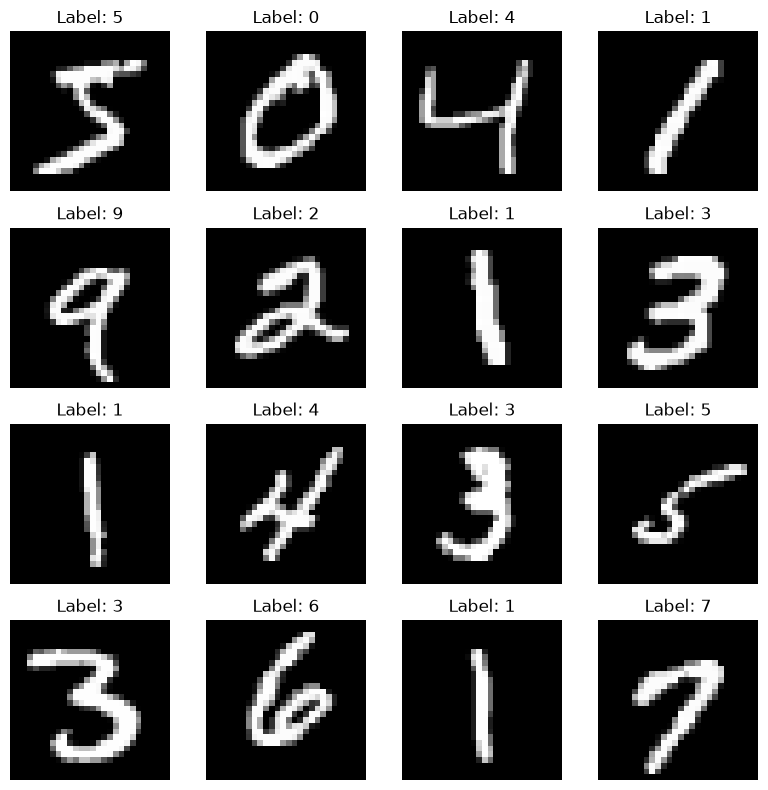

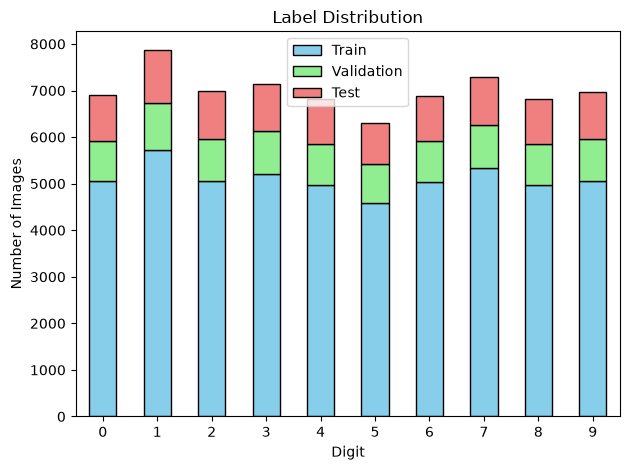

Epoch: 1/25 | Train Loss: 0.1620 | Train Accuracy: 0.9491
Validation Loss: 0.0491 | Validation Accuracy: 0.9851
Epoch: 2/25 | Train Loss: 0.0598 | Train Accuracy: 0.9815
Validation Loss: 0.0339 | Validation Accuracy: 0.9888
Epoch: 3/25 | Train Loss: 0.0437 | Train Accuracy: 0.9865
Validation Loss: 0.0355 | Validation Accuracy: 0.9902
Epoch: 4/25 | Train Loss: 0.0338 | Train Accuracy: 0.9895
Validation Loss: 0.0304 | Validation Accuracy: 0.9913
Epoch: 5/25 | Train Loss: 0.0288 | Train Accuracy: 0.9911
Validation Loss: 0.0326 | Validation Accuracy: 0.9906
Epoch: 6/25 | Train Loss: 0.0246 | Train Accuracy: 0.9920
Validation Loss: 0.0339 | Validation Accuracy: 0.9899
Epoch: 7/25 | Train Loss: 0.0215 | Train Accuracy: 0.9932
Validation Loss: 0.0348 | Validation Accuracy: 0.9914
Epoch: 8/25 | Train Loss: 0.0203 | Train Accuracy: 0.9931
Validation Loss: 0.0315 | Validation Accuracy: 0.9917
Epoch: 9/25 | Train Loss: 0.0165 | Train Accuracy: 0.9945
Validation Loss: 0.0293 | Validation Accuracy:

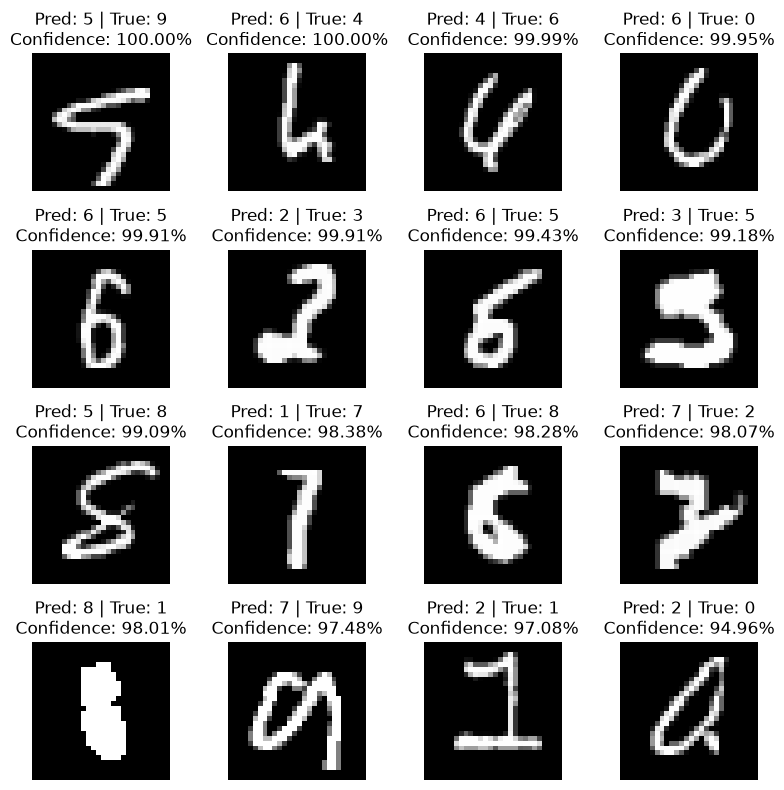

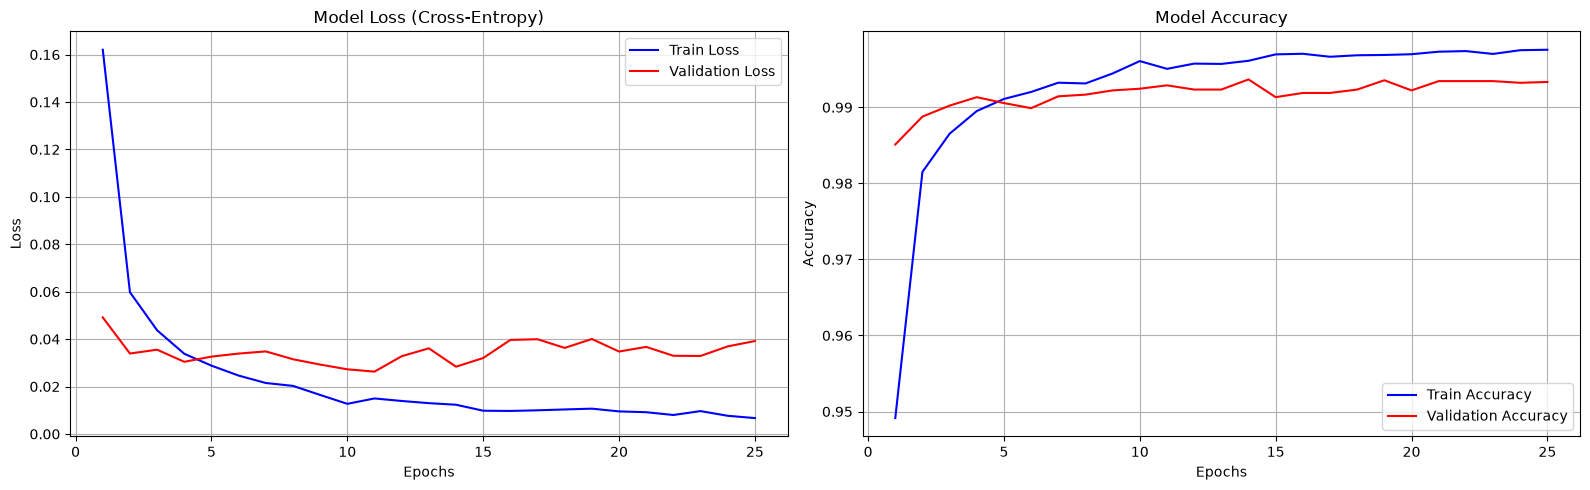

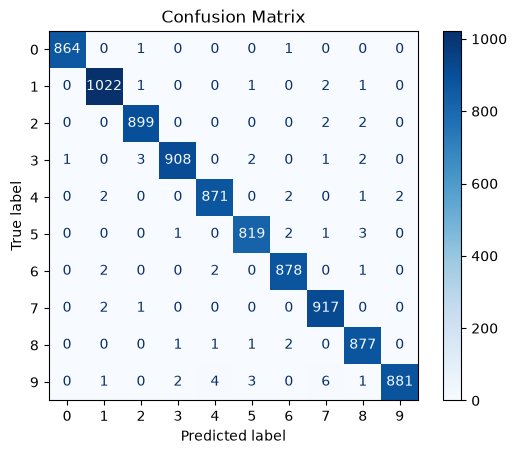

Accuracy: 0.9941
Precision: 0.9940
Recall: 0.9941
F1 score: 0.9940
Confusion Matrix:
[[ 976    0    0    0    2    0    1    1    0    0]
 [   0 1135    0    0    0    0    0    0    0    0]
 [   0    0 1027    0    0    0    0    5    0    0]
 [   0    0    0 1003    0    6    0    0    1    0]
 [   0    0    0    0  978    0    1    0    0    3]
 [   0    0    0    2    0  889    1    0    0    0]
 [   0    2    0    0    2    4  949    0    1    0]
 [   0    3    1    0    0    0    0 1021    1    2]
 [   1    0    1    0    0    0    0    0  972    0]
 [   0    0    1    0    5    7    0    3    2  991]]
# of incorrect predictions: 59


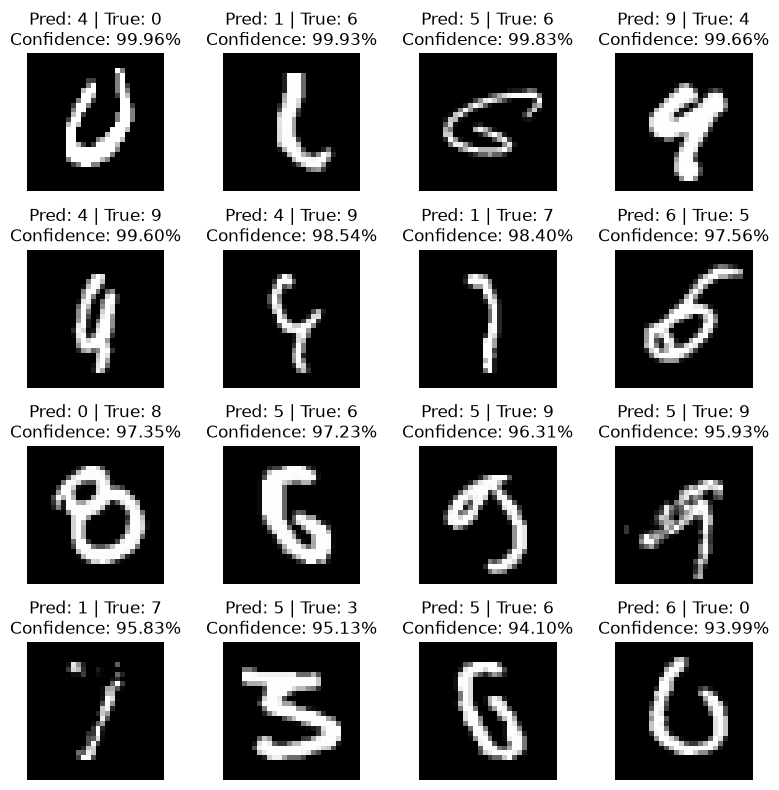

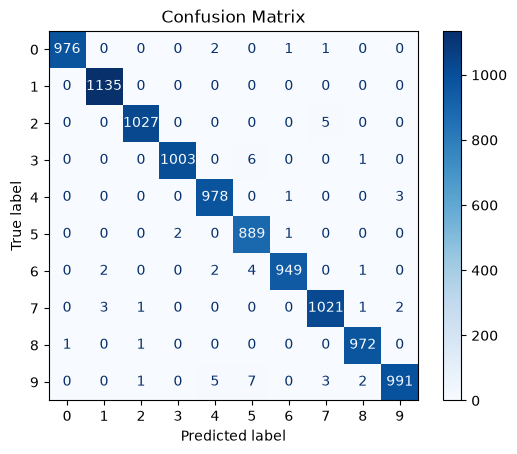

In [13]:
if __name__ == '__main__':
    (model, history, best_results, 
     confusion_matrix_val, incorrect_preds_val
     ) = main()